# 04. 이탈(Churn) 피처 & 라벨링

목표는 두 가지:
1. **이탈 기준일 N 확정**: 01_eda의 재방문 간격 수치(중앙값 3일/평균 6.5일/75%가 8일 이내)는
   2019-10~11월 2개월 스냅샷 기준이었음. 여기서는 7개월 전체로 재검증해서 N을 근거와 함께 확정.
2. **이탈 라벨 & 세그먼트 피처 생성**: 유저별 마지막 활동일 기준 이탈 여부를 라벨링하되,
   데이터 종료일(2020-04-30) 근처에 활동한 유저는 "아직 이탈할 시간이 없었을 뿐"인
   **우측 절단(right-censoring)** 문제가 있음 → 이런 유저는 `censored`로 별도 표시하고
   이탈률 집계에서 제외.

**메모리 전략**: 02_cohort_retention과 같은 원리로, 달마다 `user_id, event_time` 2개 컬럼만
읽어 날짜(day) 단위로 정규화한 뒤 `(user_id, date)` 조합만 남기고 원본은 버린다. 재방문 간격
계산에는 "그 유저가 그날 활동했는지"만 필요하고 개별 이벤트 시각·타입은 필요 없기 때문에,
수억 건의 원본 이벤트 대신 훨씬 가벼운 유저-활동일 테이블로 7개월 전체를 처리한다.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import config
from src import load

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

plt.rcParams["font.family"] = "AppleGothic"  # 맥북 한글 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

## 1. 유저-활동일(day) 테이블 추출

7개 파일을 순서대로 스캔하며, 달마다 `user_id, event_time`만 읽어 날짜로 정규화한 뒤
중복 제거한 `(user_id, date)` 조합만 모은다.

In [2]:
month_labels = ["2019-10", "2019-11", "2019-12", "2020-01", "2020-02", "2020-03", "2020-04"]

daily_activity_frames = []
for label, path in zip(month_labels, config.RAW_PATHS):
    df = load.load_month(path, usecols=["user_id", "event_time"])
    df["date"] = df["event_time"].dt.normalize()
    daily = df[["user_id", "date"]].drop_duplicates()
    del df

    daily_activity_frames.append(daily)
    print(f"{label}: 유저-활동일 조합 {len(daily):,}건")

user_activity_days = pd.concat(daily_activity_frames, ignore_index=True)
del daily_activity_frames

mem_mb = user_activity_days.memory_usage(deep=True).sum() / 1e6
print(f"user_activity_days: {user_activity_days.shape[0]:,} rows, {mem_mb:,.1f} MB")

2019-10: 유저-활동일 조합 6,473,723건


2019-11: 유저-활동일 조합 8,621,421건


2019-12: 유저-활동일 조합 9,984,617건


2020-01: 유저-활동일 조합 9,039,523건


2020-02: 유저-활동일 조합 8,526,097건


2020-03: 유저-활동일 조합 8,325,825건


2020-04: 유저-활동일 조합 9,256,607건


user_activity_days: 60,227,813 rows, 963.6 MB


## 2. 재방문 간격(day diff) 계산

유저별로 활동일을 정렬한 뒤, 연속된 활동일 사이의 간격(일)을 계산한다.
첫 활동일은 이전 활동이 없으므로 간격 계산에서 제외(NaN → dropna).

In [3]:
user_activity_days = user_activity_days.sort_values(["user_id", "date"]).reset_index(drop=True)
user_activity_days["prev_date"] = user_activity_days.groupby("user_id")["date"].shift(1)
user_activity_days["gap_days"] = (user_activity_days["date"] - user_activity_days["prev_date"]).dt.days

revisit_gaps = user_activity_days["gap_days"].dropna()
print(f"재방문 간격 샘플 수: {len(revisit_gaps):,}")
revisit_gaps.describe()

재방문 간격 샘플 수: 44,588,010


count    4.458801e+07
mean     1.268894e+01
std      2.097301e+01
min      1.000000e+00
25%      1.000000e+00
50%      4.000000e+00
75%      1.400000e+01
max      2.120000e+02
Name: gap_days, dtype: float64

## 3. 간격 분포 통계 & 퍼센타일

In [4]:
percentiles = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99]
revisit_gaps.quantile(percentiles)

0.50      4.0
0.60      7.0
0.70     11.0
0.75     14.0
0.80     18.0
0.85     24.0
0.90     35.0
0.95     55.0
0.99    107.0
Name: gap_days, dtype: float64

## 4. 분포 시각화

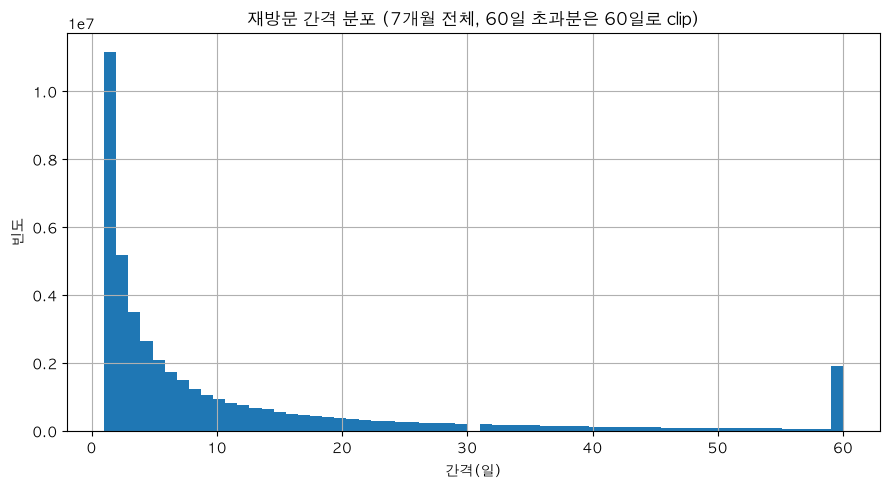

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
revisit_gaps.clip(upper=60).hist(bins=61, ax=ax)
ax.set_title("재방문 간격 분포 (7개월 전체, 60일 초과분은 60일로 clip)")
ax.set_xlabel("간격(일)")
ax.set_ylabel("빈도")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "04_revisit_gap_distribution.png", dpi=150)
plt.show()

## 5. N=30일 확정

퍼센타일 결과 90%가 35일 이내에 재방문했음 → 35일에 가까운 라운드 넘버이면서 이커머스
업계에서 흔히 쓰는 "30일 비활성=이탈" 룰과도 맞는 **N=30일**로 확정. `config.CHURN_INACTIVITY_DAYS`에 반영함.

## 6. 이탈 라벨링 (churned / retained / censored)

**우측 절단 처리 방식**: 데이터 종료일(`dataset_end`)에서 N일을 뺀 시점을 `reference_date`로
잡는다. 그러면 `reference_date` 이전에 이미 활동 이력이 있는 유저는 `reference_date` 이후
~ `dataset_end`까지 정확히 N일의 "관찰 창(observation window)"을 온전히 확보한 상태가 된다.

- `reference_date` 이전에 활동 이력이 있고, 그 이후 N일 관찰 창 안에서 재방문 →
  **retained**(재방문 확인됨)
- `reference_date` 이전에 활동 이력이 있는데, N일 관찰 창 안에서 재방문 없음 →
  **churned**(N일 무활동을 끝까지 관찰했으므로 확정)
- `reference_date` 이후(최근 N일 내)에 처음 등장한 유저 → 이 유저가 이탈할지 여부를
  판단할 "이전 이력"이 없으므로 **censored**(판단 보류, 너무 최근에 유입되어 아직
  결론 낼 수 없음)

이 방식이면 재방문 여부를 실제로 "확인"한 유저만 churned/retained로 확정하고, 아직
관찰 시간이 부족한 유저는 censored로 분리해 이탈률 계산에서 제외할 수 있다.

In [6]:
dataset_end = user_activity_days["date"].max()
reference_date = dataset_end - pd.Timedelta(days=config.CHURN_INACTIVITY_DAYS)

print(f"dataset_end: {dataset_end.date()}")
print(f"reference_date (dataset_end - {config.CHURN_INACTIVITY_DAYS}일): {reference_date.date()}")

before_users = set(user_activity_days.loc[user_activity_days["date"] <= reference_date, "user_id"])
after_users = set(user_activity_days.loc[user_activity_days["date"] > reference_date, "user_id"])

churned_users = before_users - after_users
retained_users = before_users & after_users
censored_users = after_users - before_users

print(f"평가 대상(reference_date 이전 이력 보유): {len(before_users):,}명")
print(f"  churned (확정 이탈): {len(churned_users):,}명 ({len(churned_users) / len(before_users):.1%})")
print(f"  retained (재방문 확인): {len(retained_users):,}명 ({len(retained_users) / len(before_users):.1%})")
print(f"censored (최근 {config.CHURN_INACTIVITY_DAYS}일 내 신규 유입, 판단 보류): {len(censored_users):,}명")

dataset_end: 2020-04-30
reference_date (dataset_end - 30일): 2020-03-31


평가 대상(reference_date 이전 이력 보유): 13,529,831명
  churned (확정 이탈): 11,130,180명 (82.3%)
  retained (재방문 확인): 2,399,651명 (17.7%)
censored (최근 30일 내 신규 유입, 판단 보류): 2,109,972명


## 7. 유저별 라벨 테이블 생성 & 저장

In [7]:
user_first_date = user_activity_days.groupby("user_id")["date"].min()
user_last_date = user_activity_days.groupby("user_id")["date"].max()

churn_labels = pd.DataFrame({
    "first_activity_date": user_first_date,
    "last_activity_date": user_last_date,
})

churn_labels["status"] = "censored"
churn_labels.loc[churn_labels.index.isin(churned_users), "status"] = "churned"
churn_labels.loc[churn_labels.index.isin(retained_users), "status"] = "retained"

churn_labels["status"].value_counts()

status
churned     11130180
retained     2399651
censored     2109972
Name: count, dtype: int64

In [8]:
out_path = config.PROC_DIR / "churn_labels.parquet"
churn_labels.reset_index().rename(columns={"index": "user_id"}).to_parquet(out_path, index=False)
print(f"저장 완료: {out_path}")

저장 완료: /Users/gimgyumin/Desktop/Developer/데이터 분석/commerce-churn-analysis/data/processed/churn_labels.parquet


## 8. 구매 관련 피처 (purchase_count / purchase_days / total_spend)

달마다 `user_id, event_time, event_type, price` 4개 컬럼만 읽고, `event_type == "purchase"`인
행만 남긴 뒤(전체의 약 1.5%) 유저별로 집계한다. `purchase_days`는 이벤트 수가 아니라
**구매가 발생한 고유 날짜 수**로 잡아, "한 번에 여러 상품을 구매"와 "여러 번 재방문해서
구매"를 구분한다(반복구매자 판단 기준).

In [9]:
purchase_frames = []
for label, path in zip(month_labels, config.RAW_PATHS):
    df = load.load_month(path, usecols=["user_id", "event_time", "event_type", "price"])
    purchases = df.loc[df["event_type"] == "purchase", ["user_id", "event_time", "price"]].copy()
    del df

    purchases["date"] = purchases["event_time"].dt.normalize()
    purchases["price"] = purchases["price"].astype("float64")  # sum 정밀도 확보

    monthly_agg = purchases.groupby("user_id").agg(
        purchase_count=("price", "size"),
        purchase_days=("date", "nunique"),
        total_spend=("price", "sum"),
    )
    del purchases

    purchase_frames.append(monthly_agg)
    print(f"{label}: 구매 유저 {len(monthly_agg):,}명")

purchase_features = pd.concat(purchase_frames).groupby("user_id").sum()
del purchase_frames

print(f"purchase_features: {purchase_features.shape[0]:,}명 (7개월 통합)")
purchase_features.head()

2019-10: 구매 유저 347,118명


2019-11: 구매 유저 441,638명


2019-12: 구매 유저 500,997명


2020-01: 구매 유저 359,105명


2020-02: 구매 유저 392,356명


2020-03: 구매 유저 453,487명


2020-04: 구매 유저 485,144명


purchase_features: 2,064,899명 (7개월 통합)


,purchase_count,purchase_days,total_spend
user_id,,,
96369466,1,1,50.709999
101875240,1,1,184.520004
107620212,1,1,244.279999
128029678,3,2,569.889999
128968633,4,2,714.010002


## 9. 활동 기반 피처 (cohort_month / active_days / active_months)

이미 만들어둔 `user_activity_days`(유저-활동일 테이블)에서 바로 뽑는다 — 추가 로드 불필요.

In [10]:
user_activity_days["year_month"] = user_activity_days["date"].dt.to_period("M")

activity_features = user_activity_days.groupby("user_id").agg(
    active_days=("date", "size"),
    active_months=("year_month", "nunique"),
)
activity_features["cohort_month"] = (
    user_activity_days.groupby("user_id")["year_month"].min().astype(str)
)

activity_features.head()

/var/folders/65/xgrfhqb5421c768r34jn92f40000gn/T/ipykernel_67257/2303892949.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  user_activity_days["year_month"] = user_activity_days["date"].dt.to_period("M")


,active_days,active_months,cohort_month
user_id,,,
10300217,1,1,2019-11
12511517,2,2,2020-02
22165363,9,3,2020-01
27396220,1,1,2020-04
29515875,9,3,2019-11


## 10. 최종 유저 피처 테이블 병합 & 저장

In [11]:
user_features = churn_labels.join(activity_features).join(purchase_features)

user_features["purchase_count"] = user_features["purchase_count"].fillna(0).astype(int)
user_features["purchase_days"] = user_features["purchase_days"].fillna(0).astype(int)
user_features["total_spend"] = user_features["total_spend"].fillna(0.0)

user_features["is_buyer"] = user_features["purchase_count"] > 0
user_features["repeat_buyer"] = user_features["purchase_days"] >= 2
user_features["recency_days"] = (dataset_end - user_features["last_activity_date"]).dt.days

user_features.head()

,first_activity_date,last_activity_date,status,active_days,active_months,cohort_month,purchase_count,purchase_days,total_spend,is_buyer,repeat_buyer,recency_days
user_id,,,,,,,,,,,,
10300217,2019-11-06 00:00:00+00:00,2019-11-06 00:00:00+00:00,churned,1,1,2019-11,0,0,0.0,False,False,176
12511517,2020-02-24 00:00:00+00:00,2020-03-08 00:00:00+00:00,churned,2,2,2020-02,0,0,0.0,False,False,53
22165363,2020-01-30 00:00:00+00:00,2020-03-13 00:00:00+00:00,churned,9,3,2020-01,0,0,0.0,False,False,48
27396220,2020-04-10 00:00:00+00:00,2020-04-10 00:00:00+00:00,censored,1,1,2020-04,0,0,0.0,False,False,20
29515875,2019-11-10 00:00:00+00:00,2020-04-23 00:00:00+00:00,retained,9,3,2019-11,0,0,0.0,False,False,7


In [12]:
print(f"전체 유저: {len(user_features):,}명")
print(f"구매 경험 있음(is_buyer): {user_features['is_buyer'].mean():.1%}")
print(f"구매자 중 반복구매자(repeat_buyer, 구매일수>=2): "
      f"{user_features.loc[user_features['is_buyer'], 'repeat_buyer'].mean():.1%}")

pd.crosstab(user_features["status"], user_features["is_buyer"], normalize="index")

전체 유저: 15,639,803명
구매 경험 있음(is_buyer): 13.2%
구매자 중 반복구매자(repeat_buyer, 구매일수>=2): 40.2%


is_buyer,False,True
status,,
censored,0.923532,0.076468
churned,0.896805,0.103195
retained,0.685381,0.314619


In [13]:
out_path = config.PROC_DIR / "user_features.parquet"
user_features.reset_index().rename(columns={"index": "user_id"}).to_parquet(out_path, index=False)
print(f"저장 완료: {out_path}")

저장 완료: /Users/gimgyumin/Desktop/Developer/데이터 분석/commerce-churn-analysis/data/processed/user_features.parquet
